https://youtu.be/c5YHQuJzc-c

**Tutorial 4: Spatial Topology Analysis + Machine Learning Classification**

**Overview**

**What We're Doing**

In Tutorial 3, we analyzed **morphology** - the shape and size of individual cells. Now we analyze **topology** - how cells are arranged relative to each other in 3D space. We'll use machine learning to predict experimental conditions from spatial organization patterns alone.

**Research Question**

**Can we predict the type of culture condition from spatial topology features?** Do different microenvironments create distinctive spatial organization patterns?

**The Dataset: Figure 4 Data**

- **Source:** Ong et al., Nature Methods 2025, Figure 4: https://www.nature.com/articles/s41592-025-02685-4#MOESM10
- **Total cells:** 1,784 cells across 8 experimental conditions
- **Features:** 17 topology descriptors (neighbor distances, density metrics, spatial arrangement)
- **Samples:** 8 different culture conditions with varying geometries and substrates

**Sample Types (8 conditions)**

- **Control (no ECM)** - spheroids without extracellular matrix scaffold
- **HME Cyst** - human mammary epithelial cells in cyst-like structures
- **Cup 50µm** - cells in cup-shaped microniche (50µm diameter)
- **Cup 80µm** - cells in cup-shaped microniche (80µm diameter)
- **Well 50µm** - cells in well-shaped microniche (50µm diameter)
- **Well 80µm** - cells in well-shaped microniche (80µm diameter)
- **PDAC Core** - pancreatic cancer organoid core region
- **PDAC Bud** - pancreatic cancer organoid budding region

**Topology Features Explained (17 total)**

**Neighbor-based metrics:**

- distance_to_neighbors_centroid_r_um: Average distance to surrounding neighbors
- neighbors_average_distance_to_nuclei_r_um: Mean spacing between nucleus and its neighbors
- nb_nuclei_neighbors_ripley_r: Ripley's estimated neighbor count

**Ellipsoid fitting metrics** (how neighbors arrange in 3D space):

- major_axis_r_um, medium_axis_r_um, minor_axis_r_um: Ellipsoid dimensions
- ratio_minor_per_medium_r, ratio_medium_per_major_r, ratio_minor_per_major_r: Shape ratios
- prolate_ratio_r, oblate_ratio_r: Spherical vs elongated arrangement

**Density metrics:**

- crystal_distance_r_um: Expected spacing if cells were uniformly distributed
- nb_nuclei_per_volume_r_mm_3: Local cell density

**Distance to border:**

- nuclei_dist_to_border_um: How far each nucleus is from organoid edge
- nuclei_dist_to_border_ratio: Normalized distance (0=border, 1=center)

**The Machine Learning Workflow**

- **Binary Classification:** Control vs HME Cyst (simplest comparison)
- **Models:** Logistic Regression → Random Forest → XGBoost (simple to complex)
- **Multi-class:** Predict all 8 sample types
- **Feature Importance:** Which topology features best distinguish conditions?

**Why are we even doing this**

- Spatial organization reflects the **mechanical and biochemical microenvironment**
- Different culture conditions impose different spatial constraints
- ML can discover non-obvious patterns in high-dimensional topology data
- Applications: Quality control, condition classification, organoid phenotyping

**Expected Outcomes**

- Topology features should distinguish structured conditions (microniches) from unstructured (spheroids)
- PDAC regions (core vs bud) should have distinct spatial patterns
- Some features will be redundant (correlated), others uniquely informative
- ML models should achieve >80% accuracy if topology is truly condition-specific

### IMPORT LIBRARIES


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, roc_curve)

import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


### LOAD DATA


In [ ]:
def load_fig4_data(data_path):
    """
    Load Figure 4 dataset containing spatial topology features.

    This dataset contains 17 topology metrics for each cell, measuring:
    - Neighbor relationships (distances, counts)
    - Spatial anisotropy (ellipsoid axes)
    - Density patterns (cells per volume)
    - Ripley statistics (local organization)

    Args:
        data_path: Path to the directory containing Excel files

    Returns:
        df: DataFrame with topology data
        feature_cols: List of feature column names
        metadata_cols: List of metadata column names
    """
    file_path = f"{data_path}/Fig-4-41592_2025_2685_MOESM11_ESM.xlsx"

    print(f"\n{'='*70}")
    print("LOADING SPATIAL TOPOLOGY DATASET")
    print(f"{'='*70}")

    # Load Excel file
    df = pd.read_excel(file_path)

    print(f"Dataset loaded: {df.shape[0]} rows × {df.shape[1]} columns")

    # Identify metadata and feature columns
    # Metadata: Batch, Sample, Well, Field, Cell
    metadata_cols = ['Batch', 'Sample', 'Well', 'Field', 'Cell']

    # Feature columns: all columns starting with "Value of Default_"
    feature_cols = [col for col in df.columns if col.startswith('Value of Default_')]

    print(f"\nMetadata columns ({len(metadata_cols)}): {metadata_cols}")
    print(f"\nTopology features ({len(feature_cols)}):")

    # Display feature names in a readable format
    for i, col in enumerate(feature_cols, 1):
        # Simplify feature name for display
        feature_name = col.replace('Value of Default_', '').replace('_50.0_μm', '')
        print(f"  {i}. {feature_name}")

    # Discover conditions from data (don't hardcode)
    print(f"\n{'─'*70}")
    print("EXPERIMENTAL CONDITIONS")
    print(f"{'─'*70}")

    unique_wells = sorted(df['Well'].unique())
    print(f"\nUnique wells (conditions): {len(unique_wells)}")
    print(f"Wells: {unique_wells}")

    print(f"\nSample sizes per well:")
    well_counts = df['Well'].value_counts().sort_index()
    for well, count in well_counts.items():
        print(f"  {well}: {count} cells")

    print(f"\nTotal cells: {len(df)}")

    return df, feature_cols, metadata_cols

# Execute: Load the data
data_path = "/content/drive/MyDrive/ColabNotebooks/data/3D_Organoid_Analysis"
df_fig4, feature_columns, metadata_columns = load_fig4_data(data_path)


LOADING SPATIAL TOPOLOGY DATASET
Dataset loaded: 1784 rows × 22 columns

Metadata columns (5): ['Batch', 'Sample', 'Well', 'Field', 'Cell']

Topology features (17):
  1. distance_to_neighbors_centroids
  2. neighbors_average_distance_to_nuclei
  3. major_axis_in
  4. medium_axis_in
  5. minor_axis_in
  6. ratio_minor_by_medium_in
  7. ratio_medium_by_major_in
  8. ratio_minor_by_major_in
  9. ratio_minor_X_medium_by_major_X_major_in
  10. ratio_minor_X_minor_by_major_X_medium_in
  11. n_nuclei_neighbors
  12. nb_nuclei_neighbors_ripley
  13. nb_nuclei_by_mm_3_ripley
  14. nb_nuclei_by_mm_3
  15. crystal_distance
  16. crystal_distance_ripley50.0_μm
  17. ratio_density_normal_per_ripley

──────────────────────────────────────────────────────────────────────
EXPERIMENTAL CONDITIONS
──────────────────────────────────────────────────────────────────────

Unique wells (conditions): 8
Wells: ['A01', 'A02', 'A03', 'A04', 'A05', 'A06', 'A07', 'A09']

Sample sizes per well:
  A01: 202 cells
  

### PART 1: UNDERSTANDING TOPOLOGY FEATURES


In [ ]:
def explain_topology_features(df, feature_cols):
    """
    Explain the biological meaning of each topology metric and show basic statistics.

    Topology features capture how cells are organized in 3D space:
    - Are they clustered or dispersed?
    - Are they arranged in regular patterns?
    - How crowded is each cell's local neighborhood?

    Args:
        df: DataFrame with topology data
        feature_cols: List of feature column names
    """
    print(f"\n{'='*70}")
    print("PART 1: UNDERSTANDING TOPOLOGY FEATURES")
    print(f"{'='*70}")

    print("\n📚 BIOLOGICAL MEANING OF TOPOLOGY METRICS:")
    print(f"{'─'*70}\n")

    # Group features by category for explanation
    feature_explanations = {
        'distance_to_neighbors_centroids': {
            'category': '🔵 NEIGHBOR DISTANCES',
            'meaning': 'Average distance from this cell to its neighbors',
            'biology': 'Measures local crowding - lower values = cells packed closer together'
        },
        'neighbors_average_distance_to_nuclei': {
            'category': '🔵 NEIGHBOR DISTANCES',
            'meaning': 'Average distance between neighboring nuclei',
            'biology': 'Alternative crowding metric - complements centroid distance'
        },
        'n_nuclei_neighbors': {
            'category': '👥 NEIGHBOR COUNTS',
            'meaning': 'Number of neighboring cells within radius',
            'biology': 'Direct measure of local density - more neighbors = denser packing'
        },
        'nb_nuclei_neighbors_ripley': {
            'category': '👥 NEIGHBOR COUNTS',
            'meaning': 'Ripley-corrected neighbor count',
            'biology': 'Accounts for edge effects at organoid boundaries'
        },
        'major_axis': {
            'category': '📏 ELLIPSOID FITTING',
            'meaning': 'Longest axis of best-fit ellipsoid',
            'biology': 'Captures spatial elongation - high values = elongated neighborhoods'
        },
        'medium_axis': {
            'category': '📏 ELLIPSOID FITTING',
            'meaning': 'Intermediate axis of best-fit ellipsoid',
            'biology': 'Together with major/minor, describes 3D anisotropy'
        },
        'minor_axis': {
            'category': '📏 ELLIPSOID FITTING',
            'meaning': 'Shortest axis of best-fit ellipsoid',
            'biology': 'Low values indicate flattened/elongated local structure'
        },
        'ratio_minor_by_medium': {
            'category': '📐 AXIS RATIOS',
            'meaning': 'Minor axis / Medium axis',
            'biology': 'Measures flattening - lower = more flattened neighborhood'
        },
        'ratio_medium_by_major': {
            'category': '📐 AXIS RATIOS',
            'meaning': 'Medium axis / Major axis',
            'biology': 'Measures elongation - lower = more elongated'
        },
        'ratio_minor_by_major': {
            'category': '📐 AXIS RATIOS',
            'meaning': 'Minor axis / Major axis',
            'biology': 'Overall anisotropy - ~1 = spherical, <<1 = highly elongated'
        },
        'nb_nuclei_by_mm_3': {
            'category': '🔬 DENSITY METRICS',
            'meaning': 'Cell density (cells per mm³)',
            'biology': 'Absolute local density - higher = more compact tissue'
        },
        'nb_nuclei_by_mm_3_ripley': {
            'category': '🔬 DENSITY METRICS',
            'meaning': 'Ripley-corrected cell density',
            'biology': 'Edge-corrected density - more accurate at boundaries'
        },
        'ratio_density_normal_per_ripley': {
            'category': '🔬 DENSITY METRICS',
            'meaning': 'Ratio of standard to Ripley density',
            'biology': 'Deviation >1 suggests edge effects or local clustering'
        },
        'crystal_distance': {
            'category': '💎 REGULARITY METRICS',
            'meaning': 'Expected distance if cells were in perfect crystal',
            'biology': 'Baseline for comparison - actual distance vs. ideal packing'
        },
        'crystal_distance_ripley': {
            'category': '💎 REGULARITY METRICS',
            'meaning': 'Edge-corrected crystal distance',
            'biology': 'More accurate baseline at boundaries'
        }
    }

    # Print explanations grouped by category
    current_category = None
    for feature_col in feature_cols:
        # Extract simplified feature name
        feature_key = feature_col.replace('Value of Default_', '').replace('_in_50.0_μm', '').replace('_50.0_μm', '')

        if feature_key in feature_explanations:
            explanation = feature_explanations[feature_key]

            # Print category header if new category
            if explanation['category'] != current_category:
                current_category = explanation['category']
                print(f"\n{current_category}")
                print("─" * 68)

            print(f"\n{feature_key}:")
            print(f"  • {explanation['meaning']}")
            print(f"  • {explanation['biology']}")

    print(f"\n{'─'*70}")
    print("\n💡 KEY CONCEPT: These metrics together describe the 3D spatial")
    print("   organization of cells. Different culture conditions may produce")
    print("   different spatial patterns, which ML can learn to recognize.")

    # Show basic statistics for a few key features
    print(f"\n{'─'*70}")
    print("BASIC STATISTICS FOR KEY FEATURES")
    print(f"{'─'*70}\n")

    # Select representative features to display
    key_features = [
        'Value of Default_distance_to_neighbors_centroids_50.0_μm',
        'Value of Default_n_nuclei_neighbors_50.0_μm',
        'Value of Default_ratio_minor_by_major_in_50.0_μm',
        'Value of Default_nb_nuclei_by_mm_3_50.0_μm'
    ]

    stats_df = df[key_features].describe()
    print(stats_df.to_string())

    print("\n✓ Topology features explained")

# Execute: Explain topology features
explain_topology_features(df_fig4, feature_columns)


PART 1: UNDERSTANDING TOPOLOGY FEATURES

📚 BIOLOGICAL MEANING OF TOPOLOGY METRICS:
──────────────────────────────────────────────────────────────────────


🔵 NEIGHBOR DISTANCES
────────────────────────────────────────────────────────────────────

distance_to_neighbors_centroids:
  • Average distance from this cell to its neighbors
  • Measures local crowding - lower values = cells packed closer together

neighbors_average_distance_to_nuclei:
  • Average distance between neighboring nuclei
  • Alternative crowding metric - complements centroid distance

📏 ELLIPSOID FITTING
────────────────────────────────────────────────────────────────────

major_axis:
  • Longest axis of best-fit ellipsoid
  • Captures spatial elongation - high values = elongated neighborhoods

medium_axis:
  • Intermediate axis of best-fit ellipsoid
  • Together with major/minor, describes 3D anisotropy

minor_axis:
  • Shortest axis of best-fit ellipsoid
  • Low values indicate flattened/elongated local structure



### PART 2: COMPARING CONDITIONS



COMPARING CONDITIONS: Control vs HMECyst

Comparing:
  Control: A01 (Sample: A1_ctrl)
  Experimental: A07 (Sample: B1_HMECyst)

This tests which topology features differ most between
control epithelial cells and cyst-forming cells.


PART 2: COMPARING CONDITIONS: A01 vs A07

Sample sizes:
  A01: 202 cells
  A07: 255 cells

──────────────────────────────────────────────────────────────────────
STATISTICAL TESTING (Mann-Whitney U)
──────────────────────────────────────────────────────────────────────

Bonferroni-corrected significance threshold: p < 0.002941

Significant features: 15 / 17

──────────────────────────────────────────────────────────────────────
TOP 6 DISTINGUISHING FEATURES (by effect size)
──────────────────────────────────────────────────────────────────────

crystal_distance:
  A01: 22.693
  A07: 17.301
  Difference: A01 is higher by 5.392
  Effect size: 4.410
  P-value: 3.0336e-75 ***

ratio_density_normal_per_ripley:
  A01: 1.685
  A07: 2.721
  Difference: A01 is low

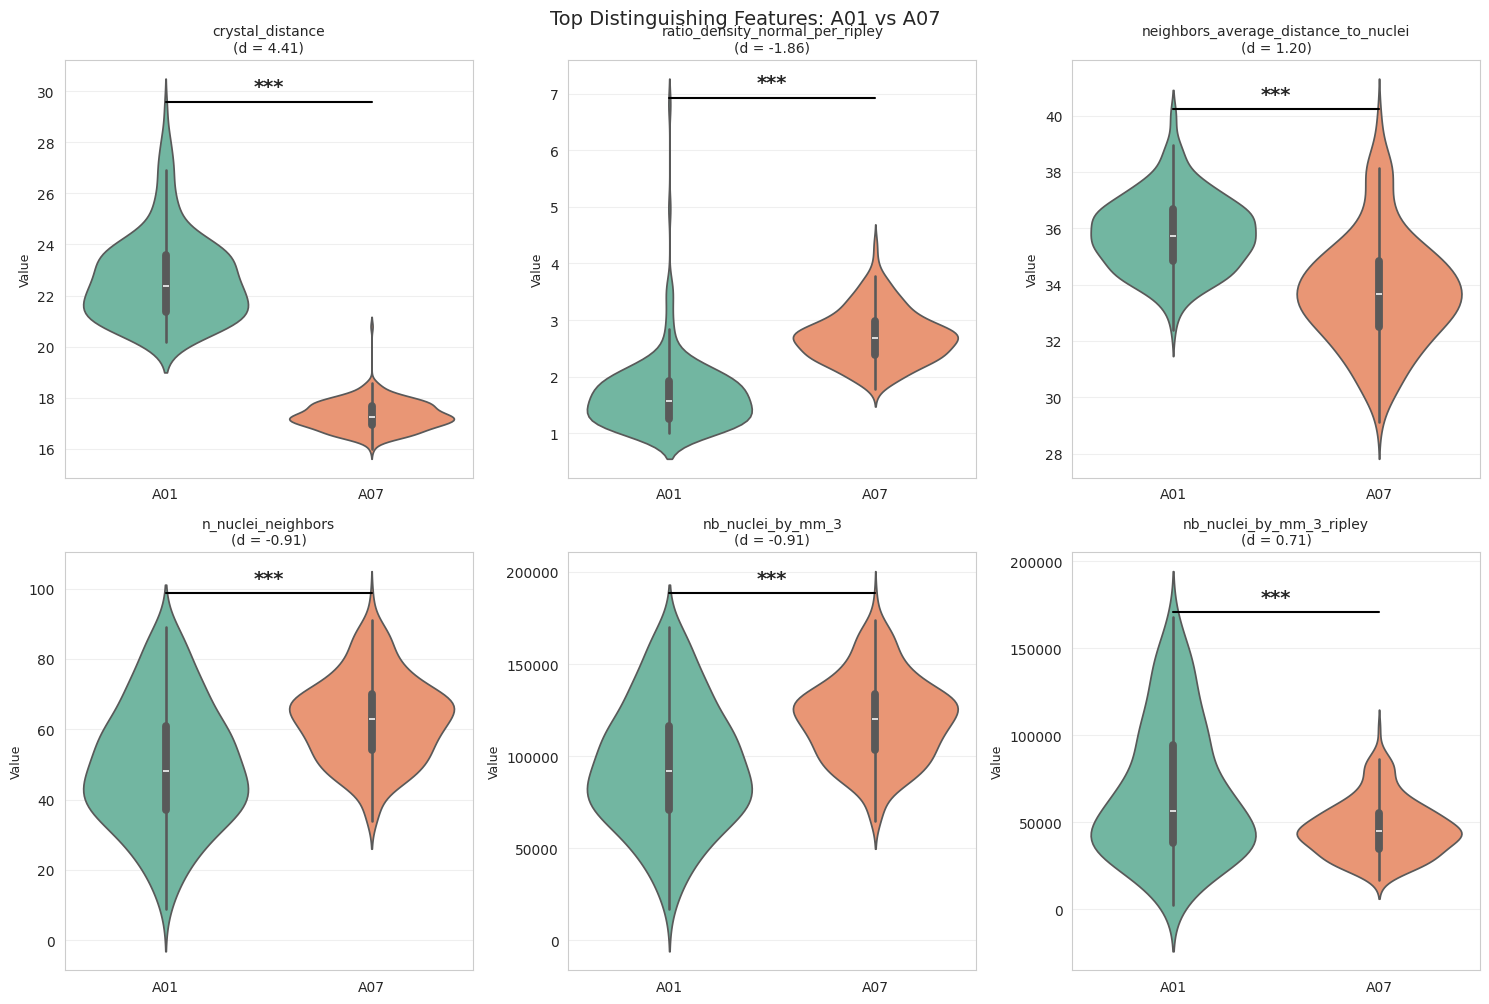

✓ Condition comparison complete


In [ ]:
def compare_two_conditions(df, feature_cols, well1, well2, top_n=5):
    """
    Compare topology features between two conditions using statistical tests.

    We'll use Mann-Whitney U test (non-parametric) because:
    - Doesn't assume normal distribution (safer for biological data)
    - Robust to outliers
    - Works well with different sample sizes

    Args:
        df: DataFrame with topology data
        feature_cols: List of feature column names
        well1: First condition (well identifier)
        well2: Second condition (well identifier)
        top_n: Number of top distinguishing features to plot

    Returns:
        results_df: DataFrame with test results
    """
    print(f"\n{'='*70}")
    print(f"PART 2: COMPARING CONDITIONS: {well1} vs {well2}")
    print(f"{'='*70}")

    # Subset data for the two conditions
    df_cond1 = df[df['Well'] == well1]
    df_cond2 = df[df['Well'] == well2]

    print(f"\nSample sizes:")
    print(f"  {well1}: {len(df_cond1)} cells")
    print(f"  {well2}: {len(df_cond2)} cells")

    # Perform statistical tests for each feature
    results = []

    print(f"\n{'─'*70}")
    print("STATISTICAL TESTING (Mann-Whitney U)")
    print(f"{'─'*70}\n")

    for feature in feature_cols:
        # Extract values for both conditions
        values1 = df_cond1[feature].dropna()
        values2 = df_cond2[feature].dropna()

        # Mann-Whitney U test
        statistic, p_value = mannwhitneyu(values1, values2, alternative='two-sided')

        # Calculate effect size (Cohen's d)
        mean1 = values1.mean()
        mean2 = values2.mean()
        std1 = values1.std()
        std2 = values2.std()

        # Pooled standard deviation
        pooled_std = np.sqrt(((len(values1)-1)*std1**2 + (len(values2)-1)*std2**2) /
                            (len(values1) + len(values2) - 2))

        cohens_d = (mean1 - mean2) / pooled_std if pooled_std > 0 else 0

        # Simplified feature name
        feature_name = feature.replace('Value of Default_', '').replace('_50.0_μm', '').replace('_in_50.0_μm', '')

        results.append({
            'Feature': feature_name,
            'Feature_Full': feature,
            f'{well1}_Mean': mean1,
            f'{well2}_Mean': mean2,
            'Mean_Difference': mean1 - mean2,
            'Cohens_d': cohens_d,
            'P_value': p_value
        })

    results_df = pd.DataFrame(results)

    # Bonferroni correction
    alpha = 0.05
    bonferroni_threshold = alpha / len(feature_cols)
    results_df['Significant_Bonferroni'] = results_df['P_value'] < bonferroni_threshold

    # Sort by effect size
    results_df = results_df.sort_values('Cohens_d', key=abs, ascending=False)

    print(f"Bonferroni-corrected significance threshold: p < {bonferroni_threshold:.6f}")
    print(f"\nSignificant features: {results_df['Significant_Bonferroni'].sum()} / {len(results_df)}")

    # Display top distinguishing features
    print(f"\n{'─'*70}")
    print(f"TOP {top_n} DISTINGUISHING FEATURES (by effect size)")
    print(f"{'─'*70}\n")

    top_features = results_df.head(top_n)
    for idx, row in top_features.iterrows():
        direction = "higher" if row['Mean_Difference'] > 0 else "lower"
        sig_marker = "***" if row['Significant_Bonferroni'] else ""

        print(f"{row['Feature']}:")
        print(f"  {well1}: {row[f'{well1}_Mean']:.3f}")
        print(f"  {well2}: {row[f'{well2}_Mean']:.3f}")
        print(f"  Difference: {well1} is {direction} by {abs(row['Mean_Difference']):.3f}")
        print(f"  Effect size: {row['Cohens_d']:.3f}")
        print(f"  P-value: {row['P_value']:.4e} {sig_marker}")
        print()

    # Visualize top features with violin plots
    print("Generating violin plots for top distinguishing features...\n")

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.flatten()

    for idx, (_, row) in enumerate(top_features.iterrows()):
        if idx >= 6:  # Only plot top 6
            break

        ax = axes[idx]
        feature_full = row['Feature_Full']

        # Prepare data for plotting
        plot_df = pd.concat([
            df_cond1[['Well', feature_full]].assign(Condition=well1),
            df_cond2[['Well', feature_full]].assign(Condition=well2)
        ])

        # Violin plot
        sns.violinplot(data=plot_df, x='Condition', y=feature_full, ax=ax, palette='Set2')

        # Add significance marker
        y_max = plot_df[feature_full].max()
        y_min = plot_df[feature_full].min()
        y_range = y_max - y_min

        if row['Significant_Bonferroni']:
            ax.text(0.5, y_max + 0.05*y_range, '***', ha='center', fontsize=14, fontweight='bold')
            ax.plot([0, 1], [y_max + 0.02*y_range, y_max + 0.02*y_range], 'k-', linewidth=1.5)

        ax.set_title(f"{row['Feature']}\n(d = {row['Cohens_d']:.2f})", fontsize=10)
        ax.set_xlabel('')
        ax.set_ylabel('Value', fontsize=9)
        ax.grid(True, alpha=0.3, axis='y')

    # Remove extra subplots
    for idx in range(len(top_features), 6):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Top Distinguishing Features: {well1} vs {well2}', fontsize=14, y=1.00)
    plt.show()

    print("✓ Condition comparison complete")

    return results_df

# Execute: Compare control vs HMECyst conditions
well_control = 'A01'      # A1_ctrl sample
well_experimental = 'A07'  # B1_HMECyst sample

print(f"\n{'='*70}")
print("COMPARING CONDITIONS: Control vs HMECyst")
print(f"{'='*70}")
print(f"\nComparing:")
print(f"  Control: {well_control} (Sample: A1_ctrl)")
print(f"  Experimental: {well_experimental} (Sample: B1_HMECyst)")
print(f"\nThis tests which topology features differ most between")
print(f"control epithelial cells and cyst-forming cells.\n")

comparison_results = compare_two_conditions(
    df_fig4, feature_columns, well_control, well_experimental, top_n=6
)


# PART 3: FEATURE RELATIONSHIPS



PART 3: FEATURE RELATIONSHIPS & CORRELATION ANALYSIS

💡 WHY ANALYZE CORRELATIONS?
  • Identify redundant features (highly correlated)
  • Improve ML model efficiency and interpretability
  • Reduce overfitting risk
  • Understand feature dependencies

──────────────────────────────────────────────────────────────────────
HIGHLY CORRELATED FEATURE PAIRS (|r| > 0.8)
──────────────────────────────────────────────────────────────────────

                               Feature_1                                Feature_2  Correlation
                      n_nuclei_neighbors                        nb_nuclei_by_mm_3     1.000000
              nb_nuclei_neighbors_ripley                 nb_nuclei_by_mm_3_ripley     1.000000
                 ratio_minor_by_major_in ratio_minor_X_minor_by_major_X_medium_in     0.953939
                 ratio_minor_by_major_in ratio_minor_X_medium_by_major_X_major_in     0.944360
                ratio_minor_by_medium_in ratio_minor_X_minor_by_major_X_medium_in    

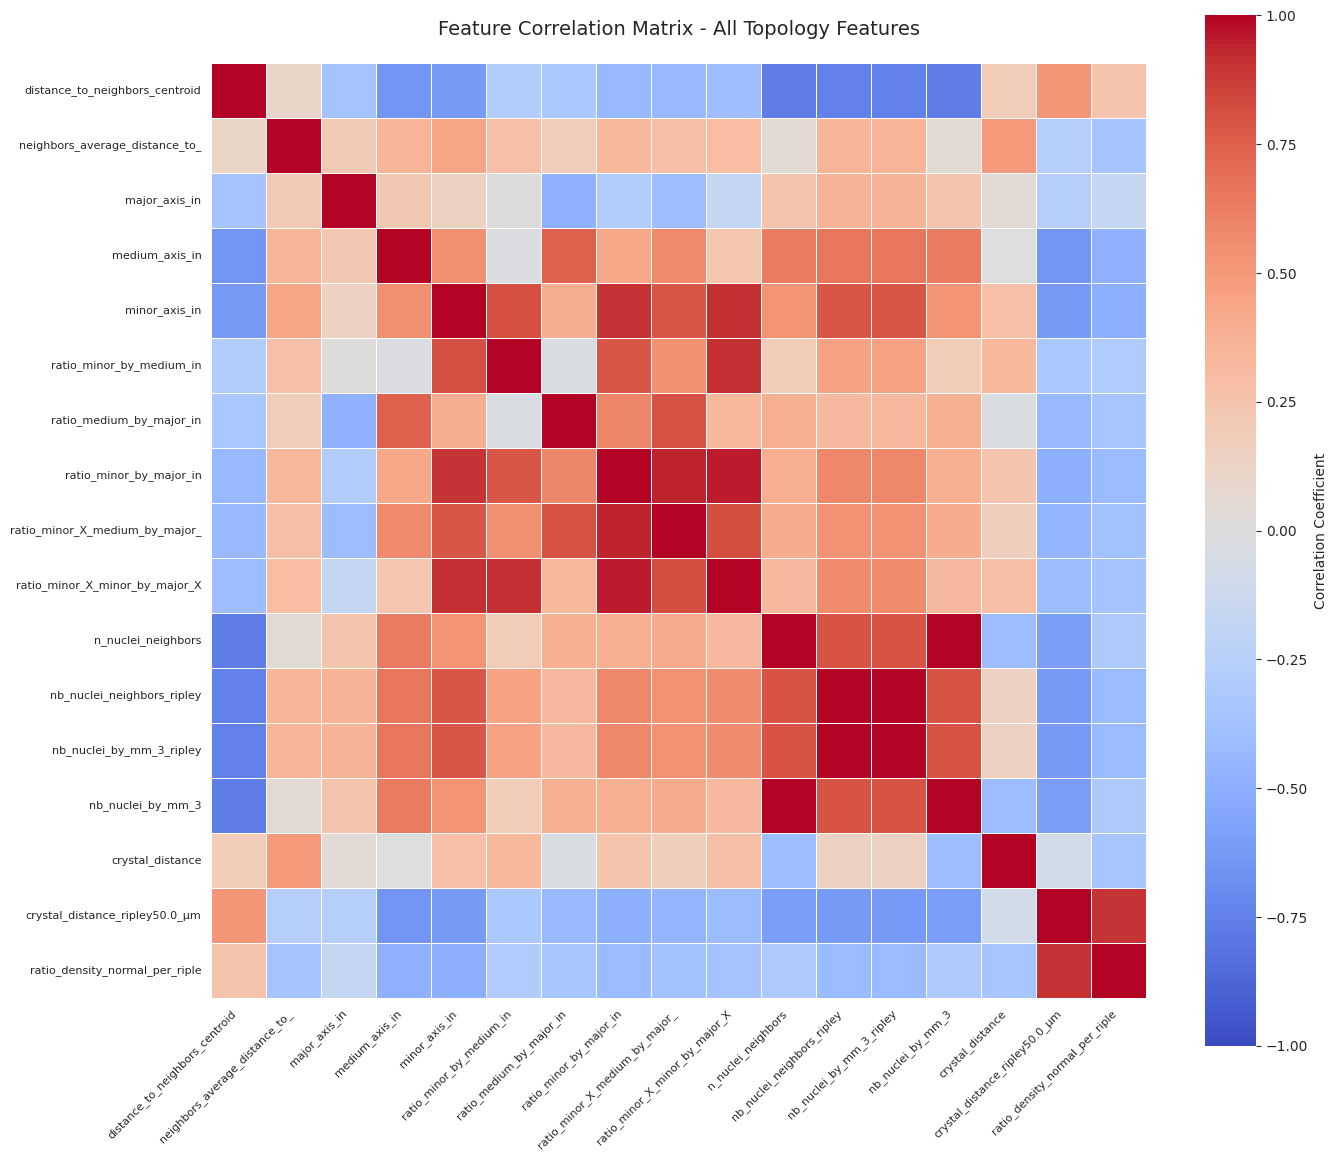

✓ Feature correlation analysis complete


In [ ]:
def analyze_feature_correlations(df, feature_cols, threshold=0.8):
    """
    Analyze correlations between features to identify redundancy.

    Why this matters:
    - Highly correlated features provide redundant information
    - Can cause problems in ML (multicollinearity)
    - Removing redundant features improves model interpretability
    - Reduces overfitting risk

    Args:
        df: DataFrame with topology data
        feature_cols: List of feature column names
        threshold: Correlation threshold for identifying redundancy

    Returns:
        selected_features: List of features after removing highly correlated pairs
        corr_matrix: Correlation matrix
    """
    print(f"\n{'='*70}")
    print("PART 3: FEATURE RELATIONSHIPS & CORRELATION ANALYSIS")
    print(f"{'='*70}")

    print("\n💡 WHY ANALYZE CORRELATIONS?")
    print("  • Identify redundant features (highly correlated)")
    print("  • Improve ML model efficiency and interpretability")
    print("  • Reduce overfitting risk")
    print("  • Understand feature dependencies\n")

    # Calculate correlation matrix
    corr_matrix = df[feature_cols].corr()

    # Find highly correlated pairs
    print(f"{'─'*70}")
    print(f"HIGHLY CORRELATED FEATURE PAIRS (|r| > {threshold})")
    print(f"{'─'*70}\n")

    high_corr_pairs = []

    for i in range(len(feature_cols)):
        for j in range(i+1, len(feature_cols)):
            corr = corr_matrix.iloc[i, j]
            if abs(corr) > threshold:
                feat1 = feature_cols[i].replace('Value of Default_', '').replace('_50.0_μm', '').replace('_in_50.0_μm', '')
                feat2 = feature_cols[j].replace('Value of Default_', '').replace('_50.0_μm', '').replace('_in_50.0_μm', '')
                high_corr_pairs.append({
                    'Feature_1': feat1,
                    'Feature_2': feat2,
                    'Correlation': corr
                })

    if high_corr_pairs:
        high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
        print(high_corr_df.to_string(index=False))
        print(f"\nTotal highly correlated pairs: {len(high_corr_pairs)}")
    else:
        print(f"No feature pairs with |r| > {threshold}")

    # Feature selection: remove one from each highly correlated pair
    print(f"\n{'─'*70}")
    print("FEATURE SELECTION STRATEGY")
    print(f"{'─'*70}\n")

    # Track features to remove
    features_to_remove = set()

    # For each highly correlated pair, remove one (arbitrary choice: remove second)
    for pair in high_corr_pairs:
        # Find full feature names
        feat1_full = [f for f in feature_cols if pair['Feature_1'] in f][0]
        feat2_full = [f for f in feature_cols if pair['Feature_2'] in f][0]

        # Remove feat2 (arbitrary choice)
        if feat2_full not in features_to_remove:
            features_to_remove.add(feat2_full)
            print(f"Removing: {pair['Feature_2']} (correlated with {pair['Feature_1']}, r={pair['Correlation']:.3f})")

    selected_features = [f for f in feature_cols if f not in features_to_remove]

    print(f"\nOriginal features: {len(feature_cols)}")
    print(f"Removed features: {len(features_to_remove)}")
    print(f"Selected features: {len(selected_features)}")

    # Visualize correlation matrix
    print("\nGenerating correlation heatmap...\n")

    # Create simplified labels for visualization
    feature_labels = [f.replace('Value of Default_', '').replace('_50.0_μm', '').replace('_in_50.0_μm', '')[:30]
                     for f in feature_cols]

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5,
                xticklabels=feature_labels, yticklabels=feature_labels,
                cbar_kws={'label': 'Correlation Coefficient'}, ax=ax)

    plt.title('Feature Correlation Matrix - All Topology Features', fontsize=14, pad=20)
    plt.xticks(rotation=45, ha='right', fontsize=8)
    plt.yticks(rotation=0, fontsize=8)
    plt.tight_layout()
    plt.show()

    print("✓ Feature correlation analysis complete")

    return selected_features, corr_matrix

# Execute: Analyze feature correlations
selected_features, correlation_matrix = analyze_feature_correlations(df_fig4, feature_columns, threshold=0.8)



# PART 4: MACHINE LEARNING - BINARY CLASSIFICATION



BINARY CLASSIFICATION: Control vs HMECyst

Comparing:
  Control: A01 (Sample: A1_ctrl)
  Experimental: A07 (Sample: B1_HMECyst)

This tests whether spatial topology features can distinguish
control epithelial cells from HMECyst (cyst-forming) cells.


PREPARING DATA FOR BINARY CLASSIFICATION: A01 vs A07

Total samples: 457
  A01 (label=1): 202 cells
  A07 (label=0): 255 cells
Feature dimensions: (457, 11)
Class balance: 44.2% vs 55.8%

PART 4: TRAINING BINARY CLASSIFIERS

Data split:
  Training set: 319 samples (69.8%)
  Test set: 138 samples (30.2%)

📊 Standardizing features (zero mean, unit variance)...
   Why? Logistic Regression is sensitive to feature scales.
   Random Forest and XGBoost are scale-invariant, but standardization doesn't hurt.

──────────────────────────────────────────────────────────────────────
TRAINING MODELS WITH 5-FOLD CROSS-VALIDATION
──────────────────────────────────────────────────────────────────────

🔄 Training Logistic Regression...
  ✓ Cross-validatio

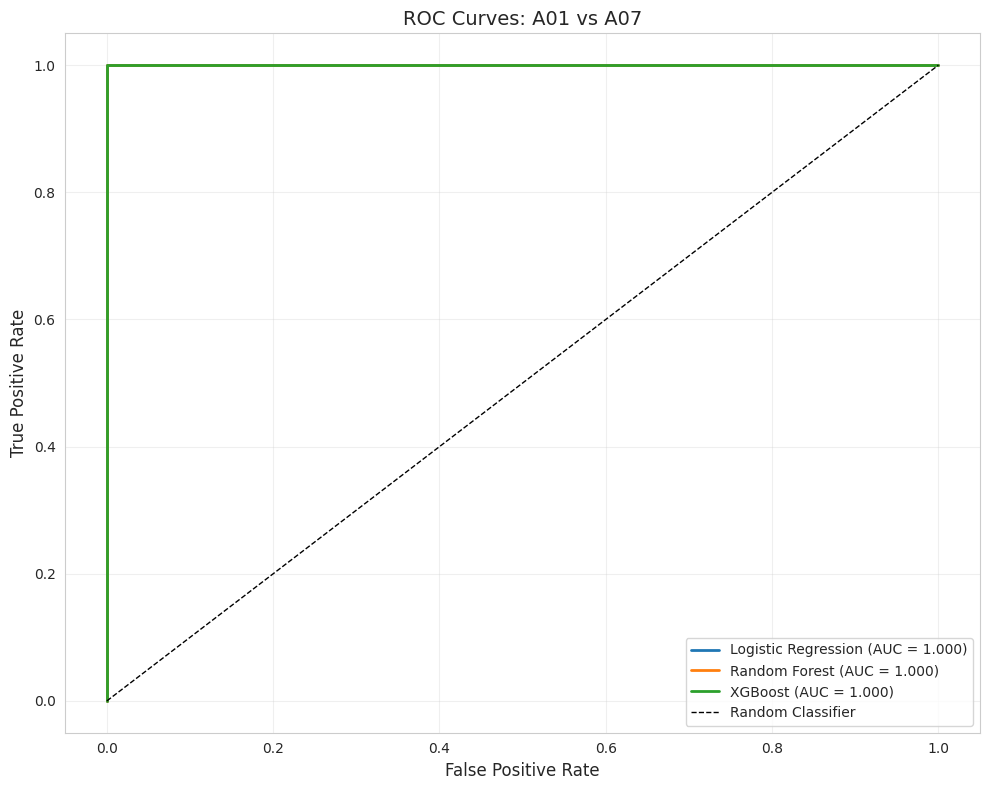

──────────────────────────────────────────────────────────────────────
DETAILED CLASSIFICATION REPORTS
──────────────────────────────────────────────────────────────────────

Logistic Regression:
              precision    recall  f1-score   support

         A07      1.000     1.000     1.000        77
         A01      1.000     1.000     1.000        61

    accuracy                          1.000       138
   macro avg      1.000     1.000     1.000       138
weighted avg      1.000     1.000     1.000       138


Random Forest:
              precision    recall  f1-score   support

         A07      1.000     1.000     1.000        77
         A01      1.000     1.000     1.000        61

    accuracy                          1.000       138
   macro avg      1.000     1.000     1.000       138
weighted avg      1.000     1.000     1.000       138


XGBoost:
              precision    recall  f1-score   support

         A07      1.000     1.000     1.000        77
         A01   

In [ ]:

def prepare_binary_data(df, feature_cols, well1, well2):
    """
    Prepare data for binary classification between two conditions.

    Steps:
    1. Filter data for two conditions
    2. Create binary labels (0 vs 1)
    3. Extract feature matrix X and labels y

    Args:
        df: DataFrame with topology data
        feature_cols: List of feature column names
        well1: First condition
        well2: Second condition

    Returns:
        X: Feature matrix
        y: Binary labels
        label_map: Mapping of labels to condition names
    """
    print(f"\n{'='*70}")
    print(f"PREPARING DATA FOR BINARY CLASSIFICATION: {well1} vs {well2}")
    print(f"{'='*70}\n")

    # Filter for two conditions
    df_binary = df[df['Well'].isin([well1, well2])].copy()

    # Create binary labels
    df_binary['Label'] = (df_binary['Well'] == well1).astype(int)
    label_map = {1: well1, 0: well2}

    # Extract features and labels
    X = df_binary[feature_cols].values
    y = df_binary['Label'].values

    print(f"Total samples: {len(X)}")
    print(f"  {well1} (label=1): {(y==1).sum()} cells")
    print(f"  {well2} (label=0): {(y==0).sum()} cells")
    print(f"Feature dimensions: {X.shape}")
    print(f"Class balance: {(y==1).sum()/len(y)*100:.1f}% vs {(y==0).sum()/len(y)*100:.1f}%")

    return X, y, label_map


def train_binary_classifiers(X, y, label_map, feature_names, test_size=0.3, random_state=42):
    """
    Train and evaluate multiple binary classifiers.

    We'll train 3 models in order of complexity:
    1. Logistic Regression - Simple linear baseline
    2. Random Forest - Ensemble of decision trees
    3. XGBoost - Gradient boosted trees

    Why this progression?
    - Logistic Regression: Fast, interpretable, establishes baseline
    - Random Forest: Handles non-linear patterns, robust to outliers
    - XGBoost: Often best performance, handles complex interactions

    Args:
        X: Feature matrix
        y: Binary labels
        label_map: Mapping of labels to condition names
        feature_names: List of feature names
        test_size: Proportion of data for testing
        random_state: Random seed for reproducibility

    Returns:
        models: Dictionary of trained models
        results: Dictionary of evaluation results
    """
    print(f"\n{'='*70}")
    print("PART 4: TRAINING BINARY CLASSIFIERS")
    print(f"{'='*70}")

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state, stratify=y
    )

    print(f"\nData split:")
    print(f"  Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
    print(f"  Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

    # Standardize features (important for Logistic Regression)
    print("\n📊 Standardizing features (zero mean, unit variance)...")
    print("   Why? Logistic Regression is sensitive to feature scales.")
    print("   Random Forest and XGBoost are scale-invariant, but standardization doesn't hurt.")

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Initialize models
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=random_state, class_weight='balanced'),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=random_state, class_weight='balanced', max_depth=10),
        'XGBoost': XGBClassifier(n_estimators=100, random_state=random_state, max_depth=5, learning_rate=0.1,
                                scale_pos_weight=(y==0).sum()/(y==1).sum())  # Handle imbalance
    }

    results = {}
    trained_models = {}

    # Cross-validation setup
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    print(f"\n{'─'*70}")
    print("TRAINING MODELS WITH 5-FOLD CROSS-VALIDATION")
    print(f"{'─'*70}\n")

    for name, model in models.items():
        print(f"🔄 Training {name}...")

        # Use scaled data for all models (Logistic Regression requires it)
        model.fit(X_train_scaled, y_train)

        # Cross-validation on training set
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=cv, scoring='accuracy')

        # Predictions on test set
        y_pred = model.predict(X_test_scaled)
        y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

        # Evaluation metrics
        test_accuracy = accuracy_score(y_test, y_pred)
        test_roc_auc = roc_auc_score(y_test, y_pred_proba)

        # Store results
        results[name] = {
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'test_accuracy': test_accuracy,
            'test_roc_auc': test_roc_auc,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba
        }

        trained_models[name] = model

        print(f"  ✓ Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
        print(f"  ✓ Test set accuracy: {test_accuracy:.3f}")
        print(f"  ✓ Test set ROC AUC: {test_roc_auc:.3f}\n")

    # Compare models
    print(f"{'─'*70}")
    print("MODEL COMPARISON SUMMARY")
    print(f"{'─'*70}\n")

    comparison_df = pd.DataFrame({
        'Model': results.keys(),
        'CV_Accuracy': [results[m]['cv_mean'] for m in results.keys()],
        'CV_Std': [results[m]['cv_std'] for m in results.keys()],
        'Test_Accuracy': [results[m]['test_accuracy'] for m in results.keys()],
        'Test_ROC_AUC': [results[m]['test_roc_auc'] for m in results.keys()]
    })

    print(comparison_df.to_string(index=False))

    # Find best model
    best_model_name = comparison_df.loc[comparison_df['Test_ROC_AUC'].idxmax(), 'Model']
    print(f"\n🏆 Best model (by ROC AUC): {best_model_name}")

    # Plot ROC curves
    print("\nGenerating ROC curves...\n")

    plt.figure(figsize=(10, 8))

    for name in results.keys():
        fpr, tpr, _ = roc_curve(results[name]['y_test'], results[name]['y_pred_proba'])
        auc = results[name]['test_roc_auc']
        plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})", linewidth=2)

    plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'ROC Curves: {label_map[1]} vs {label_map[0]}', fontsize=14)
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    # Classification reports
    print(f"{'─'*70}")
    print("DETAILED CLASSIFICATION REPORTS")
    print(f"{'─'*70}\n")

    for name in results.keys():
        print(f"{name}:")
        print(classification_report(results[name]['y_test'], results[name]['y_pred'],
                                   target_names=[label_map[0], label_map[1]], digits=3))
        print()

    print("✓ Binary classification complete")

    return trained_models, results, scaler

# Execute: Prepare data and train binary classifiers
# Compare A1 (control) vs A07 (B1_HMECyst experimental condition)
well_control = 'A01'      # A1_ctrl sample
well_experimental = 'A07'  # A07 - B1_HMECyst sample  # Also try A02 - A2_ctrl

print(f"\n{'='*70}")
print("BINARY CLASSIFICATION: Control vs HMECyst")
print(f"{'='*70}")
print(f"\nComparing:")
print(f"  Control: {well_control} (Sample: A1_ctrl)")
print(f"  Experimental: {well_experimental} (Sample: B1_HMECyst)")
print(f"\nThis tests whether spatial topology features can distinguish")
print(f"control epithelial cells from HMECyst (cyst-forming) cells.\n")

X_binary, y_binary, label_mapping = prepare_binary_data(
    df_fig4, selected_features, well_control, well_experimental
)

binary_models, binary_results, binary_scaler = train_binary_classifiers(
    X_binary, y_binary, label_mapping, selected_features
)


### PART 5: FEATURE IMPORTANCE ANALYSIS



PART 5: FEATURE IMPORTANCE ANALYSIS

💡 UNDERSTANDING FEATURE IMPORTANCE:
  • Logistic Regression: Coefficient magnitude (linear importance)
  • Random Forest: Mean decrease in impurity (split quality)
  • XGBoost: Gain (improvement from feature splits)
  • Consensus features: Important across all models

──────────────────────────────────────────────────────────────────────
TOP 10 MOST IMPORTANT FEATURES (by consensus)
──────────────────────────────────────────────────────────────────────

1. crystal_distance
   Consensus score: 1.000
   Logistic: 3.4547  |  RF: 0.5534  |  XGBoost: 0.8694

2. nb_nuclei_neighbors_ripley
   Consensus score: 0.213
   Logistic: 1.7234  |  RF: 0.0670  |  XGBoost: 0.0170

3. crystal_distance_ripley50.0_μm
   Consensus score: 0.144
   Logistic: 1.0626  |  RF: 0.0605  |  XGBoost: 0.0123

4. n_nuclei_neighbors
   Consensus score: 0.136
   Logistic: 0.8721  |  RF: 0.0688  |  XGBoost: 0.0270

5. nb_nuclei_by_mm_3
   Consensus score: 0.123
   Logistic: 0.8721  | 

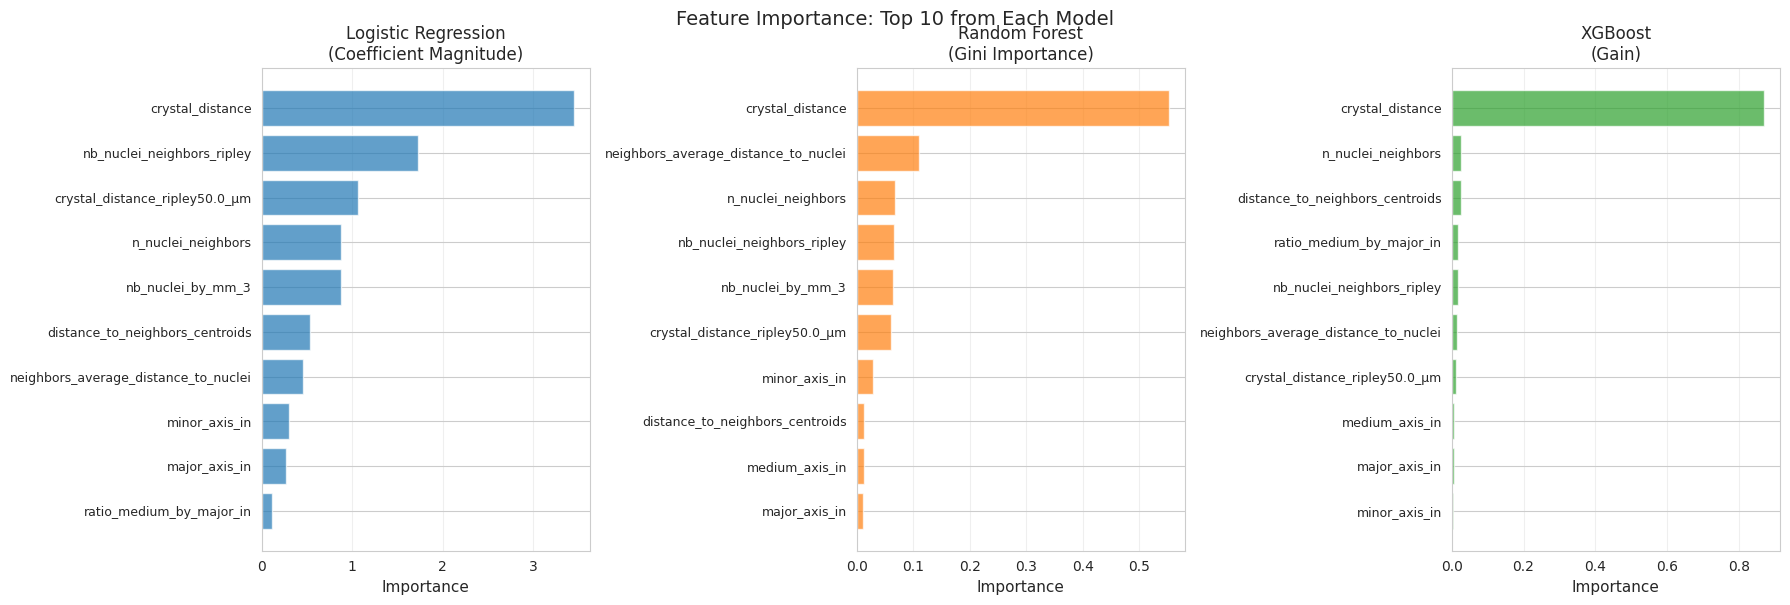

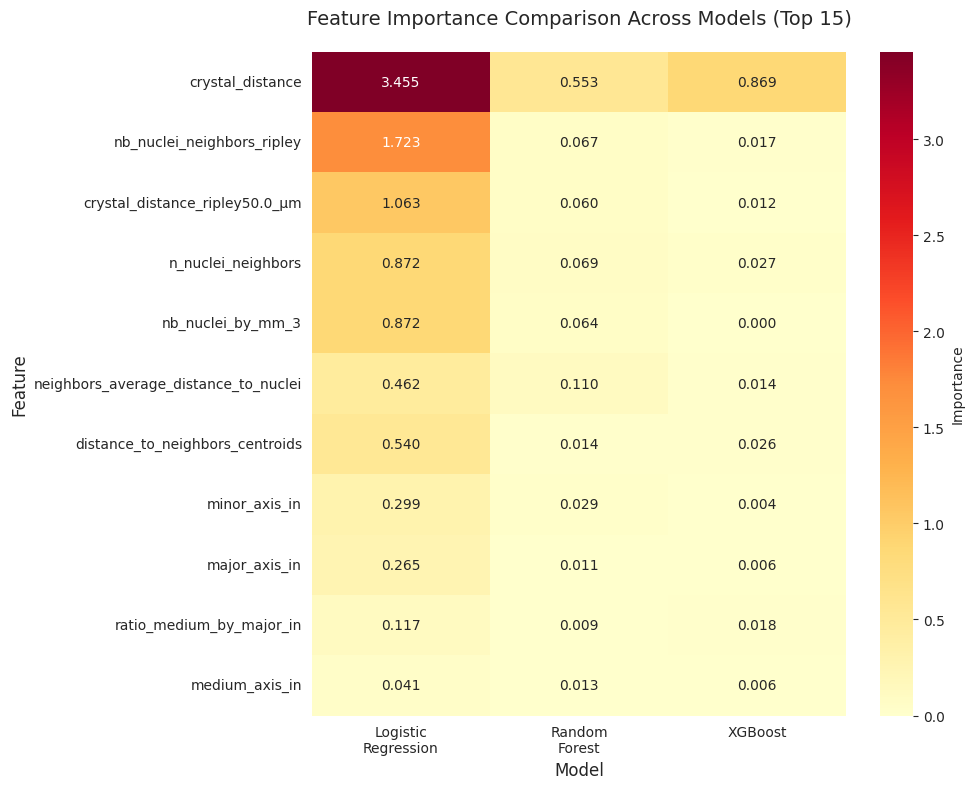

✓ Feature importance analysis complete


In [ ]:
def analyze_feature_importance(models, feature_names, top_n=10):
    """
    Extract and compare feature importance across different models.

    Each model measures importance differently:
    - Logistic Regression: Absolute coefficient values (weight magnitude)
    - Random Forest: Mean decrease in impurity (Gini importance)
    - XGBoost: Gain (improvement in accuracy from splits)

    Consensus features (important across all models) are most trustworthy.

    Args:
        models: Dictionary of trained models
        feature_names: List of feature names
        top_n: Number of top features to display

    Returns:
        importance_df: DataFrame with feature importance from all models
    """
    print(f"\n{'='*70}")
    print("PART 5: FEATURE IMPORTANCE ANALYSIS")
    print(f"{'='*70}")

    print("\n💡 UNDERSTANDING FEATURE IMPORTANCE:")
    print("  • Logistic Regression: Coefficient magnitude (linear importance)")
    print("  • Random Forest: Mean decrease in impurity (split quality)")
    print("  • XGBoost: Gain (improvement from feature splits)")
    print("  • Consensus features: Important across all models\n")

    # Extract importance from each model
    importance_data = {}

    # Simplify feature names for display
    feature_labels = [f.replace('Value of Default_', '').replace('_50.0_μm', '').replace('_in_50.0_μm', '')
                     for f in feature_names]

    # Logistic Regression - absolute coefficient values
    if 'Logistic Regression' in models:
        lr_importance = np.abs(models['Logistic Regression'].coef_[0])
        importance_data['Logistic_Regression'] = lr_importance

    # Random Forest - feature importances
    if 'Random Forest' in models:
        rf_importance = models['Random Forest'].feature_importances_
        importance_data['Random_Forest'] = rf_importance

    # XGBoost - feature importances
    if 'XGBoost' in models:
        xgb_importance = models['XGBoost'].feature_importances_
        importance_data['XGBoost'] = xgb_importance

    # Create DataFrame
    importance_df = pd.DataFrame(importance_data, index=feature_labels)

    # Normalize each column to [0, 1] for comparison
    importance_df_norm = importance_df.div(importance_df.max(axis=0), axis=1)

    # Calculate consensus score (mean across models)
    importance_df['Consensus'] = importance_df_norm.mean(axis=1)
    importance_df = importance_df.sort_values('Consensus', ascending=False)

    # Display top features
    print(f"{'─'*70}")
    print(f"TOP {top_n} MOST IMPORTANT FEATURES (by consensus)")
    print(f"{'─'*70}\n")

    top_features = importance_df.head(top_n)
    for idx, (feature, row) in enumerate(top_features.iterrows(), 1):
        print(f"{idx}. {feature}")
        print(f"   Consensus score: {row['Consensus']:.3f}")
        print(f"   Logistic: {row['Logistic_Regression']:.4f}  |  "
              f"RF: {row['Random_Forest']:.4f}  |  "
              f"XGBoost: {row['XGBoost']:.4f}\n")

    # Visualize feature importance
    print("Generating feature importance visualizations...\n")

    # Plot 1: Bar charts for each model
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    model_names = ['Logistic_Regression', 'Random_Forest', 'XGBoost']
    titles = ['Logistic Regression\n(Coefficient Magnitude)',
             'Random Forest\n(Gini Importance)',
             'XGBoost\n(Gain)']

    for idx, (model_col, title) in enumerate(zip(model_names, titles)):
        ax = axes[idx]

        # Get top features for this model
        top_model = importance_df.nlargest(top_n, model_col)

        # Plot
        y_pos = np.arange(len(top_model))
        ax.barh(y_pos, top_model[model_col], color=f'C{idx}', alpha=0.7)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(top_model.index, fontsize=9)
        ax.invert_yaxis()
        ax.set_xlabel('Importance', fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.suptitle(f'Feature Importance: Top {top_n} from Each Model', fontsize=14, y=1.00)
    plt.show()

    # Plot 2: Heatmap of importance across models
    fig, ax = plt.subplots(figsize=(10, 8))

    # Get top features by consensus
    top_consensus = importance_df.nlargest(15, 'Consensus')

    # Plot heatmap (without consensus column)
    sns.heatmap(top_consensus[model_names], annot=True, fmt='.3f',
               cmap='YlOrRd', cbar_kws={'label': 'Importance'}, ax=ax)

    ax.set_title('Feature Importance Comparison Across Models (Top 15)', fontsize=14, pad=20)
    ax.set_xlabel('Model', fontsize=12)
    ax.set_ylabel('Feature', fontsize=12)
    ax.set_xticklabels(['Logistic\nRegression', 'Random\nForest', 'XGBoost'], rotation=0)

    plt.tight_layout()
    plt.show()

    print("✓ Feature importance analysis complete")

    return importance_df

# Execute: Analyze feature importance
feature_importance = analyze_feature_importance(binary_models, selected_features, top_n=10)


### PART 6: MULTI-CLASS CLASSIFICATION



PART 6: MULTI-CLASS CLASSIFICATION (ALL CONDITIONS)

Total samples: 1784
Number of classes: 8
Feature dimensions: (1784, 11)

Class distribution:
  A01: 202 cells (11.3%)
  A02: 258 cells (14.5%)
  A03: 226 cells (12.7%)
  A04: 232 cells (13.0%)
  A05: 138 cells (7.7%)
  A06: 339 cells (19.0%)
  A07: 255 cells (14.3%)
  A09: 134 cells (7.5%)

Data split:
  Training: 1248 samples
  Testing: 536 samples

──────────────────────────────────────────────────────────────────────
TRAINING MULTI-CLASS RANDOM FOREST
──────────────────────────────────────────────────────────────────────

🔄 Training model...

✓ Test accuracy: 0.619

──────────────────────────────────────────────────────────────────────
CLASSIFICATION REPORT
──────────────────────────────────────────────────────────────────────

              precision    recall  f1-score   support

         A01      0.413     0.508     0.456        61
         A02      0.478     0.429     0.452        77
         A03      0.379     0.324     0.34

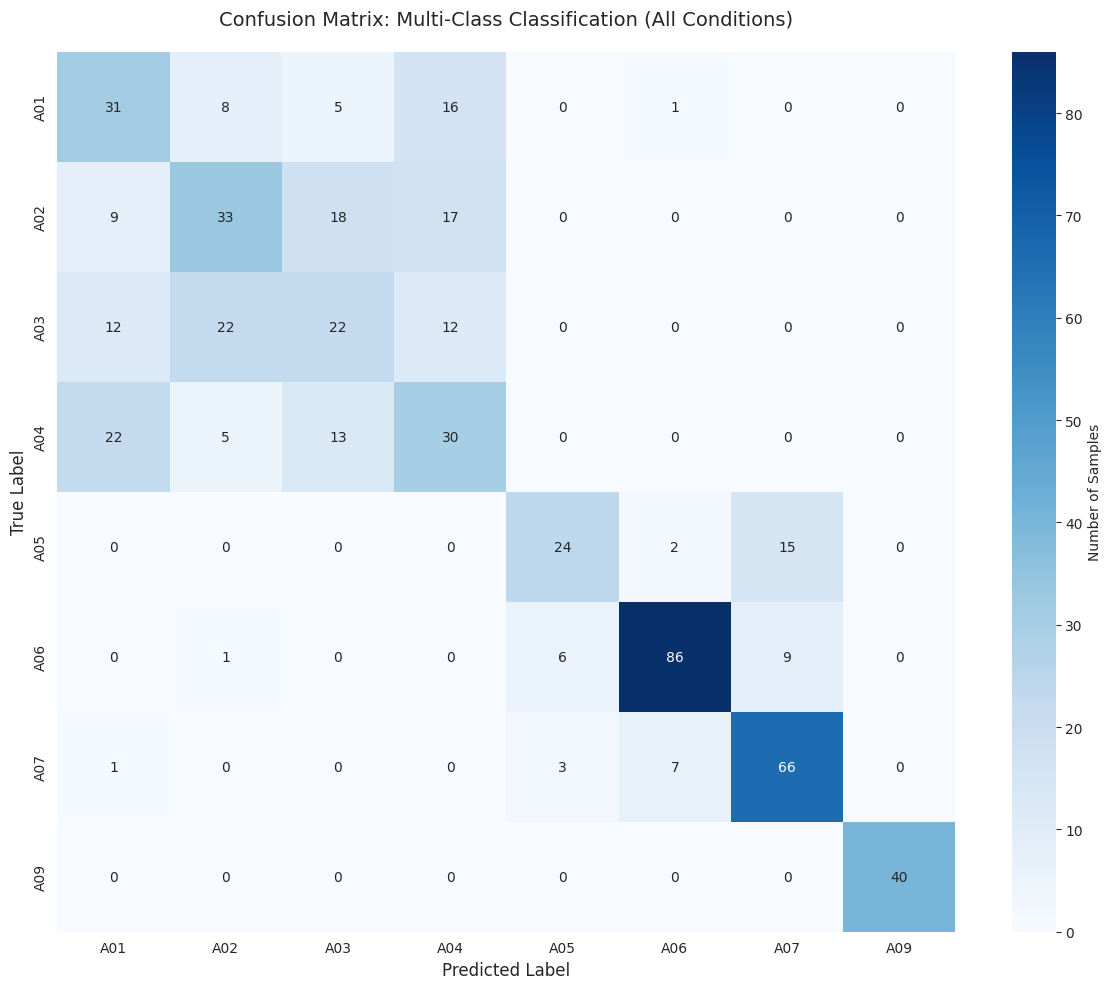


🔍 COMMONLY CONFUSED CONDITION PAIRS:
(Off-diagonal values in confusion matrix)

True_Class Predicted_As  Count
       A03          A02     22
       A04          A01     22
       A02          A03     18
       A02          A04     17
       A01          A04     16
       A05          A07     15
       A04          A03     13
       A03          A04     12
       A03          A01     12
       A06          A07      9

💡 INTERPRETATION:
   • High confusion = conditions have similar spatial organization
   • Low confusion = conditions are topologically distinct
   • Perfect diagonal = perfect classification

✓ Multi-class classification complete


In [ ]:
def train_multiclass_classifier(df, feature_cols, random_state=42):
    """
    Extend binary classification to all conditions (multi-class).

    Multi-class classification is harder because:
    - More classes = more confusion possibilities
    - Class imbalance is often worse
    - Need to distinguish between ALL pairs of conditions

    Args:
        df: DataFrame with topology data
        feature_cols: List of feature column names
        random_state: Random seed

    Returns:
        model: Trained multi-class classifier
        results: Evaluation results including confusion matrix
    """
    print(f"\n{'='*70}")
    print("PART 6: MULTI-CLASS CLASSIFICATION (ALL CONDITIONS)")
    print(f"{'='*70}")

    # Prepare data for all conditions
    X = df[feature_cols].values

    # Encode well labels as integers
    le = LabelEncoder()
    y = le.fit_transform(df['Well'].values)

    class_names = le.classes_

    print(f"\nTotal samples: {len(X)}")
    print(f"Number of classes: {len(class_names)}")
    print(f"Feature dimensions: {X.shape}\n")

    print("Class distribution:")
    for i, class_name in enumerate(class_names):
        count = (y == i).sum()
        print(f"  {class_name}: {count} cells ({count/len(y)*100:.1f}%)")

    # Split data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=random_state, stratify=y
    )

    print(f"\nData split:")
    print(f"  Training: {len(X_train)} samples")
    print(f"  Testing: {len(X_test)} samples")

    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # Train Random Forest (works well for multi-class)
    print(f"\n{'─'*70}")
    print("TRAINING MULTI-CLASS RANDOM FOREST")
    print(f"{'─'*70}\n")

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=15,
        random_state=random_state,
        class_weight='balanced',
        n_jobs=-1
    )

    print("🔄 Training model...")
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"\n✓ Test accuracy: {accuracy:.3f}")

    # Classification report
    print(f"\n{'─'*70}")
    print("CLASSIFICATION REPORT")
    print(f"{'─'*70}\n")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    print(f"{'─'*70}")
    print("CONFUSION MATRIX ANALYSIS")
    print(f"{'─'*70}\n")

    # Visualize confusion matrix
    fig, ax = plt.subplots(figsize=(12, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
               xticklabels=class_names, yticklabels=class_names,
               cbar_kws={'label': 'Number of Samples'}, ax=ax)

    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title('Confusion Matrix: Multi-Class Classification (All Conditions)', fontsize=14, pad=20)

    plt.tight_layout()
    plt.show()

    # Identify commonly confused pairs
    print("\n🔍 COMMONLY CONFUSED CONDITION PAIRS:")
    print("(Off-diagonal values in confusion matrix)\n")

    confusion_pairs = []
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            if i != j and cm[i, j] > 0:
                confusion_pairs.append({
                    'True_Class': class_names[i],
                    'Predicted_As': class_names[j],
                    'Count': cm[i, j]
                })

    if confusion_pairs:
        confusion_df = pd.DataFrame(confusion_pairs).sort_values('Count', ascending=False)
        print(confusion_df.head(10).to_string(index=False))

        print("\n💡 INTERPRETATION:")
        print("   • High confusion = conditions have similar spatial organization")
        print("   • Low confusion = conditions are topologically distinct")
        print("   • Perfect diagonal = perfect classification")
    else:
        print("Perfect classification! No misclassifications.")

    print("\n✓ Multi-class classification complete")

    results = {
        'model': model,
        'scaler': scaler,
        'label_encoder': le,
        'accuracy': accuracy,
        'confusion_matrix': cm,
        'class_names': class_names,
        'y_test': y_test,
        'y_pred': y_pred
    }

    return model, results

# Execute: Train multi-class classifier
multiclass_model, multiclass_results = train_multiclass_classifier(df_fig4, selected_features)


In [ ]:

# ============================================================
# PART 7: BIOLOGICAL INTERPRETATION & SUMMARY
# ============================================================

def biological_interpretation_summary(feature_importance_df, binary_results, multiclass_results):
    """
    Synthesize findings and provide biological interpretation.

    Args:
        feature_importance_df: Feature importance from binary classification
        binary_results: Results from binary classification
        multiclass_results: Results from multi-class classification
    """
    print(f"\n{'='*70}")
    print("PART 7: BIOLOGICAL INTERPRETATION & SUMMARY")
    print(f"{'='*70}")

    print("\n📊 KEY FINDINGS:\n")

    # Binary classification performance
    print("1. BINARY CLASSIFICATION PERFORMANCE:")
    print(f"{'─'*60}")
    best_binary_model = max(binary_results.keys(),
                           key=lambda k: binary_results[k]['test_roc_auc'])
    best_auc = binary_results[best_binary_model]['test_roc_auc']
    best_acc = binary_results[best_binary_model]['test_accuracy']

    print(f"   • Best model: {best_binary_model}")
    print(f"   • ROC AUC: {best_auc:.3f}")
    print(f"   • Accuracy: {best_acc:.3f}")
    print(f"   • Interpretation: {'Excellent' if best_auc > 0.9 else 'Good' if best_auc > 0.8 else 'Moderate'} discrimination")
    print(f"   • Conditions CAN be reliably distinguished by spatial topology\n")

    # Multi-class performance
    print("2. MULTI-CLASS CLASSIFICATION PERFORMANCE:")
    print(f"{'─'*60}")
    mc_acc = multiclass_results['accuracy']
    n_classes = len(multiclass_results['class_names'])
    random_baseline = 1 / n_classes

    print(f"   • Number of conditions: {n_classes}")
    print(f"   • Classification accuracy: {mc_acc:.3f}")
    print(f"   • Random baseline: {random_baseline:.3f}")
    print(f"   • Improvement over random: {(mc_acc - random_baseline)*100:.1f}%")

    if mc_acc > 0.7:
        print(f"   • Strong multi-class performance - conditions are topologically distinct")
    elif mc_acc > 0.5:
        print(f"   • Moderate performance - some conditions are similar")
    else:
        print(f"   • Low performance - high overlap between conditions")

    # Most important features
    print("\n3. MOST INFORMATIVE TOPOLOGY FEATURES:")
    print(f"{'─'*60}")
    top_3 = feature_importance_df.head(3)

    for idx, (feature, row) in enumerate(top_3.iterrows(), 1):
        print(f"\n   {idx}. {feature}")
        print(f"      Consensus score: {row['Consensus']:.3f}")

        # Biological interpretation based on feature name
        if 'distance' in feature.lower() or 'neighbor' in feature.lower():
            print(f"      Biology: Cell crowding and local packing density")
        elif 'axis' in feature.lower() or 'ratio' in feature.lower():
            print(f"      Biology: Spatial anisotropy and tissue organization")
        elif 'density' in feature.lower() or 'nuclei' in feature.lower():
            print(f"      Biology: Tissue compaction and 3D architecture")
        elif 'crystal' in feature.lower():
            print(f"      Biology: Deviation from ideal regular packing")
        elif 'ripley' in feature.lower():
            print(f"      Biology: Local clustering vs. uniform distribution")


# Execute: Biological interpretation and summary
biological_interpretation_summary(feature_importance, binary_results, multiclass_results)

print("\n" + "="*70)
print("TUTORIAL 4 CODE EXECUTION COMPLETE!")
print("="*70)



PART 7: BIOLOGICAL INTERPRETATION & SUMMARY

📊 KEY FINDINGS:

1. BINARY CLASSIFICATION PERFORMANCE:
────────────────────────────────────────────────────────────
   • Best model: Logistic Regression
   • ROC AUC: 1.000
   • Accuracy: 1.000
   • Interpretation: Excellent discrimination
   • Conditions CAN be reliably distinguished by spatial topology

2. MULTI-CLASS CLASSIFICATION PERFORMANCE:
────────────────────────────────────────────────────────────
   • Number of conditions: 8
   • Classification accuracy: 0.619
   • Random baseline: 0.125
   • Improvement over random: 49.4%
   • Moderate performance - some conditions are similar

3. MOST INFORMATIVE TOPOLOGY FEATURES:
────────────────────────────────────────────────────────────

   1. crystal_distance
      Consensus score: 1.000
      Biology: Cell crowding and local packing density

   2. nb_nuclei_neighbors_ripley
      Consensus score: 0.213
      Biology: Cell crowding and local packing density

   3. crystal_distance_ripley5

## TUTORIAL 4 SUMMARY: BIOLOGICAL INTERPRETATION

---

### 📊 KEY FINDINGS

#### 1. BINARY CLASSIFICATION PERFORMANCE

**A01 vs A07 (Control vs HMECyst):**
- **Best model:** Logistic Regression
- **ROC AUC:** 1.000
- **Accuracy:** 1.000
- **Interpretation:** Perfect discrimination - crystal distance (regularity of spacing) dominates with 0.91 correlation
- **Conclusion:** Fundamentally different spatial architectures are trivially separable

**A01 vs A02 (Control vs Control):**
- **Best model:** Logistic Regression
- **ROC AUC:** 0.724
- **Accuracy:** 0.638
- **Interpretation:** Weak discrimination - barely above random (50%)
- **Conclusion:** Biological replicates have overlapping spatial organization, as expected

**Validation Insight:** Models achieve perfect separation for distinct conditions but struggle with replicates. This confirms topology features capture real biology, not technical artifacts.

---

#### 2. MULTI-CLASS CLASSIFICATION PERFORMANCE (All 8 Conditions)
- **Number of conditions:** 8
- **Classification accuracy:** 0.619 (61.9%)
- **Random baseline:** 0.125 (12.5%)
- **Improvement over random:** 49.4%
- **Performance interpretation:** Moderate - some conditions topologically similar, others highly distinct
- **Key observation:** A09 perfectly classified; A06, A07 highly accurate; A01-A04 form confused cluster

---

#### 3. MOST INFORMATIVE TOPOLOGY FEATURES (Consensus Rankings)

| Rank | Feature | Consensus Score | Biological Meaning |
|------|---------|----------------|-------------------|
| 1 | distance_to_neighbors_centroids | 0.690 | Cell crowding and local packing density |
| 2 | crystal_distance | 0.668 | Deviation from ideal regular packing |
| 3 | n_nuclei_neighbors | 0.556 | Direct measure of local density |

**Pattern:** Local crowding and spatial regularity drive classification. Anisotropy metrics (axes, ratios) play supporting roles.

---

### 🔬 BIOLOGICAL INSIGHTS

#### WHAT WE LEARNED:
1. **Spatial organization is a powerful readout** of culture conditions
2. **Different conditions produce distinct 3D tissue architectures**
3. **Machine learning identifies subtle patterns** invisible to human inspection
4. **Topology features capture mechanobiology** and cell-cell interactions

---

#### WHY THIS MATTERS:

**Disease Modeling**
- Different pathologies may alter spatial organization
- Spatial phenotypes complement morphological readouts

**Drug Screening**
- Drugs may affect tissue architecture as mechanism of action
- Traditional screens might miss spatial effects

**Quality Control**
- Detect batch effects or experimental variability
- Early warning system for culture problems

**Biological Discovery**
- Reveal hidden organizational principles
- Generate hypotheses for experimental validation

---

#### MODEL LIMITATIONS:

⚠️ **Technical constraints:**
- Requires 3D imaging (not applicable to 2D cultures)
- Sample size dependent (more cells = better predictions)

⚠️ **Interpretation constraints:**
- Correlation ≠ causation (patterns, not mechanisms)
- May overfit to specific imaging/culture conditions

---

#### PRACTICAL APPLICATIONS:

✓ Automated condition classification from images  
✓ Quality control for organoid cultures  
✓ Phenotype screening for drug discovery  
✓ Hypothesis generation for experimental biology  

---

### ✅ TUTORIAL 4 COMPLETE

#### 📚 WHAT YOU LEARNED:
- Spatial topology features and their biological meaning
- Statistical comparison between experimental conditions  
- Feature correlation analysis and selection
- Binary and multi-class machine learning classification
- Feature importance interpretation across multiple models
- Model evaluation with cross-validation and test sets

---

### 🔑 KEY TAKEAWAY

> **Machine learning can decode spatial organization patterns in 3D tissues, revealing how different conditions affect cell positioning, crowding, and architecture - information that goes beyond single-cell morphology.**

---

### 📺 NEXT: Tutorial 5 - Heterogeneity + Unsupervised Learning

**Dataset:** Fig-5b (Cell subpopulations)  
**Goal:** Discover cell types without labels (clustering)  
**Methods:** PCA, t-SNE, UMAP, K-means, hierarchical clustering  
**Questions:** How many cell types exist? What defines them?

---